# Rossman Store Sales: Forecasting

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import warnings

# Add the parent directory (project root) to sys.path if not already there
parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

warnings.filterwarnings("ignore")

In [ ]:
import warnings
import mlflow
import random
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import performance_metrics, cross_validation

from IPython.core.display_functions import display

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score

from src.preprocessing import preprocess_rossmann_data
from src.preprocessing import prepare_cluster_data_for_training, split_cluster_data
from src.utils.evaluation import evaluate_model_performance_on_stores, smape

from src.preprocessing import (
    create_lags_features_rossmann,
    create_rolling_stats_features_rossmann
)

## Load datasets

In [4]:
DATA_PATH = "../data/"

train = pd.read_csv(f"{DATA_PATH}/train.csv", parse_dates=["Date"])
test = pd.read_csv(f"{DATA_PATH}/test.csv", parse_dates=["Date"])
store = pd.read_csv(f"{DATA_PATH}/store.csv")

train = train.merge(store, on="Store")
test = test.merge(store, on="Store")

print("Train dataset:")
display(train.head())
display(f"Train size: {train.shape}")

print("Test dataset:")
display(test.head())
display(f"Test size: {test.shape}")

Train dataset:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


'Train size: (1017209, 18)'

Test dataset:


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN


'Test size: (41088, 17)'

## Preprocessing

In [5]:
ptrain = preprocess_rossmann_data(df=train)
ptest = preprocess_rossmann_data(df=test)

ptrain.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,year,month,days_to_competitor
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,1270.0,9.0,2008.0,0,NaN,NaN,NaN,2015,7,2768
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,3133
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,3498
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,620.0,9.0,2009.0,0,NaN,NaN,NaN,2015,7,2402
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,29910.0,4.0,2015.0,0,NaN,NaN,NaN,2015,7,211


## Modeling

Build forecasting models for Rossmann stores

In [7]:
mlflow.set_tracking_uri("http://localhost:5001/")
mlflow.set_experiment("forecasting_rossmann_hybrid_clustering")

<Experiment: artifact_location='s3://mlflow-artifacts/9', creation_time=1777994873269, experiment_id='9', last_update_time=1777994873269, lifecycle_stage='active', name='forecasting_rossmann_hybrid_clustering', tags={}, trace_location=None, workspace='default'>

### (baseline) Modeling: Prophet

Building one model for each store is not feasible since it's 1110+ store.
Therefore, the initial idea is to **cluster stores and then build models for each cluster**. <br>
First, we build a profile (Avg. Sales and Avg. Customers) for each store. Then, we cluster store profiles.

It's important to mention that one model for all stores is also not possible since we learned from EDA
that we some store are quite different.

#### Create groups

In [6]:
# Create a store profile
store_features = ptrain.groupby("Store").agg({
    "Sales": "mean",
    "Customers": "mean",
    "CompetitionDistance": "mean"
}).reset_index()

store_features = store_features.merge(store[["Store", "StoreType"]], on="Store")

store_features.columns = ['Store', 'AvgSales', 'AvgCustomers', "AvgCompetitionDistance", 'StoreType']
# Tested features: "SchoolHoliday", "Open", "Promo", "Promo2", 'StoreType'

display(store_features.head())

,Store,AvgSales,AvgCustomers,AvgCompetitionDistance,StoreType
0,1,3945.704883,467.646497,1270.0,c
1,2,4122.991507,486.045648,570.0,a
2,3,5741.253715,620.286624,14130.0,a
3,4,8021.769639,1100.057325,620.0,c
4,5,3867.110403,444.360934,29910.0,a


In [7]:
num_features = ["AvgSales", "AvgCustomers"]
cat_features = ["StoreType"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(), cat_features)
    ]
)

X_processed = preprocessor.fit_transform(store_features)

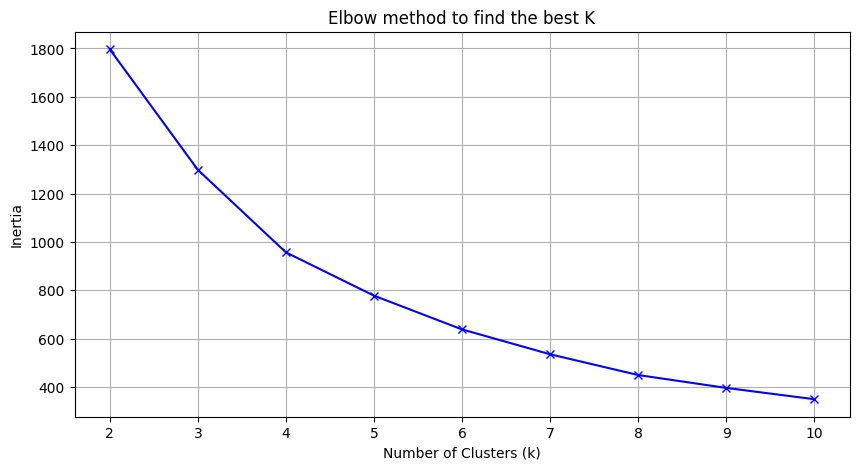

Silhouette scores:


{2: 0.4766256837305637,
 3: 0.3322185620054336,
 4: 0.40191892541792695,
 5: 0.47127705399623565,
 6: 0.45204740321966036,
 7: 0.4620760450667053,
 8: 0.44695612870700835,
 9: 0.46076497271348893,
 10: 0.4496019015853945}

In [8]:
inertia = []
scores = {}

K = range(2,11)

for k in K:
    kmodel = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmodel.fit(X_processed)
    inertia.append(kmodel.inertia_)
    score = silhouette_score(X_processed, kmodel.labels_)
    scores[k] = score

plt.figure(figsize=(10, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow method to find the best K")
plt.grid(True)
plt.show()

print("Silhouette scores:")
display(scores)

**Notes**
- According to Silhouette scores, *k=2* and *k=5* have good scores.
- *K=5* looks a bit overlapped when we plot the clusters.
- However, it's important to check the distribution of each cluster before jumping into modeling.
- Also, we test different *K's* (from 5 to 9) to see which one gives better sMAPE scores.

In [9]:
NUM_K = 9

kmeans = KMeans(n_clusters=NUM_K, random_state=42, n_init=10)
store_features["Cluster"] = kmeans.fit_predict(X_processed)

store_features.head()

,Store,AvgSales,AvgCustomers,AvgCompetitionDistance,StoreType,Cluster
0,1,3945.704883,467.646497,1270.0,c,6
1,2,4122.991507,486.045648,570.0,a,1
2,3,5741.253715,620.286624,14130.0,a,4
3,4,8021.769639,1100.057325,620.0,c,0
4,5,3867.110403,444.360934,29910.0,a,1


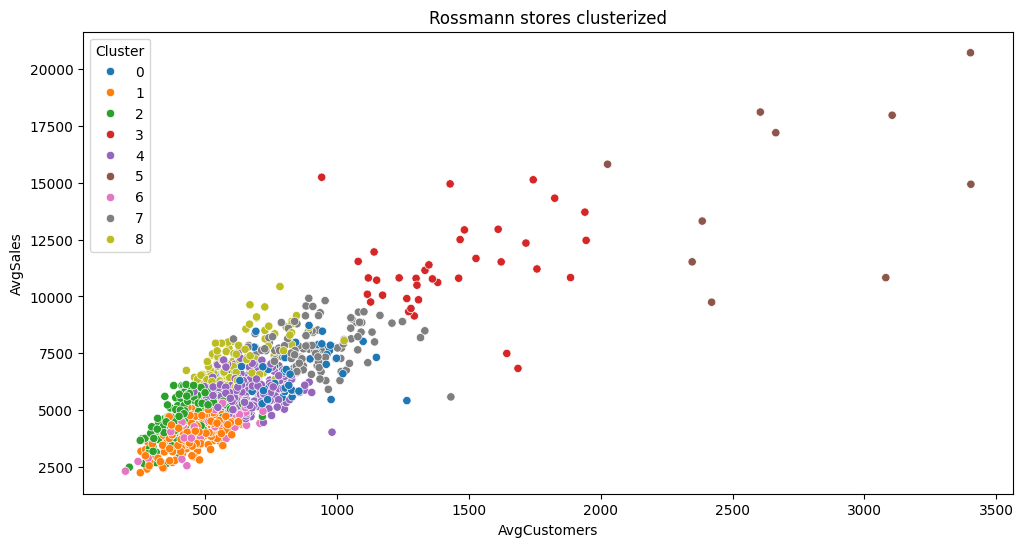

In [10]:
fig, ax = plt.subplots(figsize=(12,6))

cluster_colors = sns.color_palette("tab10")
sns.scatterplot(
    data=store_features,
    x="AvgCustomers",
    y="AvgSales",
    hue="Cluster",
    palette=cluster_colors
)
ax.set(title="Rossmann stores clusterized");


StoreType Distribution inside Clusters:


StoreType,a,b,c,d
Cluster,,,,
0,0,1,65,0
1,249,0,0,0
2,0,0,0,221
3,25,4,7,1
4,220,2,0,0
5,3,7,0,0
6,0,0,76,0
7,105,3,0,0
8,0,0,0,126


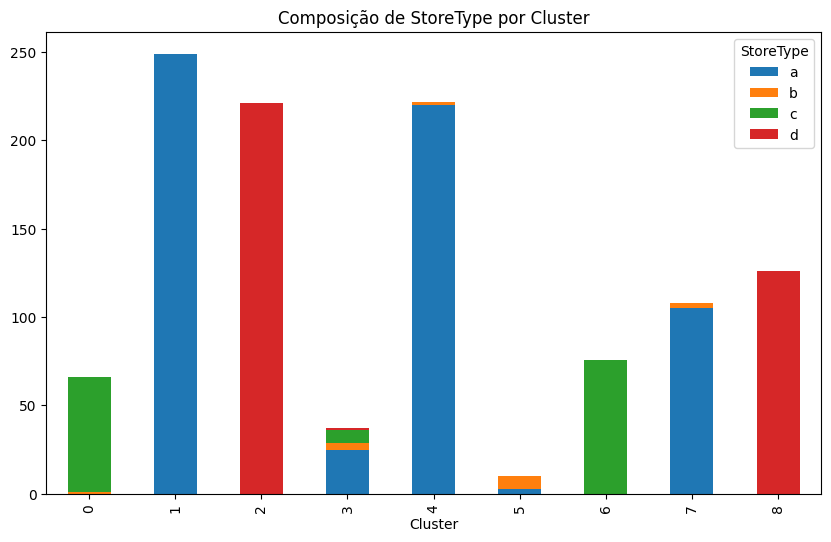

In [11]:
distribution_type = pd.crosstab(store_features['Cluster'], store_features['StoreType'])
print("\nStoreType Distribution inside Clusters:")
display(distribution_type)

distribution_type.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Composição de StoreType por Cluster')
plt.legend(title='StoreType')
plt.show()

In [12]:
cluster_sale_desc = store_features.groupby("Cluster")["AvgSales"].describe()
cluster_sale_desc.sort_values("mean").round(2)

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
1,249.0,4000.19,653.17,2244.50,3539.16,4012.90,4509.67,5477.61
6,76.0,4420.24,773.20,2313.47,4042.14,4441.60,4949.30,5805.72
2,221.0,4792.75,786.52,2485.84,4266.79,4877.63,5444.09,6126.55
4,222.0,5843.08,632.50,4027.61,5378.87,5812.55,6225.03,7588.34
0,66.0,6661.60,915.05,5276.15,5891.38,6606.41,7298.74,8857.61
8,126.0,7054.71,958.69,5727.35,6334.87,6774.94,7551.96,10433.38
7,108.0,7820.55,868.02,5579.38,7259.64,7710.06,8428.53,9917.41
3,37.0,11200.74,1919.07,6833.67,10053.74,10814.83,12346.30,15242.11
5,10.0,15014.83,3600.64,9744.60,11968.51,15373.69,17777.22,20718.52


#### Build models

In [30]:
train_size = 0.8
cluster_features = ["ds", "y", "Open", "Promo", "DayOfWeek"]
rn = random.getrandbits(16)

forecasts_test = pd.DataFrame() #{}
models_results = {}

for cluster_id in range(NUM_K):
    run_name = f"[{rn}] Cluster_{cluster_id}"
    print(f"Running cluster {cluster_id}")

    with mlflow.start_run(run_name=run_name):

        agg_x, cluster_ptrain = prepare_cluster_data_for_training(
            store_features=store_features,
            ptrain=ptrain,
            cluster_id=cluster_id,
            cluster_features=cluster_features
        )

        agg_x_train, agg_x_test, cap_by_day = split_cluster_data(
            train_size=train_size,
            agg_x=agg_x,
            margin=1.5
        )

        model = Prophet(
            seasonality_mode="multiplicative",
            growth="logistic"
        )
        model.add_country_holidays("DE")
        model.add_regressor("Open", mode="multiplicative")
        model.add_regressor("Promo", mode="multiplicative")
        model.fit(agg_x_train)

        future = model.make_future_dataframe(periods=agg_x_test.shape[0])
        future["Open"] = agg_x["Open"]
        future["Promo"] = agg_x["Promo"]
        future["DayOfWeek"] = agg_x["DayOfWeek"]
        future["cap"] = future["DayOfWeek"].map(cap_by_day)
        future["floor"] = 0

        forecast = model.predict(future)

        df_cv = cross_validation(
            model,
            initial="540 days",
            period="90 days",
            horizon="30 days",
            parallel="processes"
        )
        df_p = performance_metrics(df_cv)

        store_forecasts, scores_smapes = evaluate_model_performance_on_stores(
            model=model,
            cluster_ptrain=cluster_ptrain,
            cluster_features=cluster_features
        )
        stores_avg_smape = np.mean(scores_smapes)

        store_forecasts["Cluster"] = cluster_id
        forecasts_test = pd.concat([
            forecasts_test, store_forecasts],
            ignore_index=True
        )

        models_results[cluster_id] = {
            "model": model,
            "forecast": forecast
        }

        num_stores = store_features[store_features["Cluster"] == cluster_id].shape[0]
        cluster_smape = df_p["smape"].mean()

        print(f"\nCluster {cluster_id} - CV sMAPE = {cluster_smape} | " +
                f"Stores avg. sMAPE = {stores_avg_smape}")

        mlflow.log_metric("avg_cluster_smape", round(cluster_smape,3))
        mlflow.log_metric("avg_store_smape", round(stores_avg_smape,3))
        mlflow.log_metric("num_clusters", NUM_K)
        mlflow.log_param("cluster_size", num_stores)


Running cluster 0


10:04:51 - cmdstanpy - INFO - Chain [1] start processing
10:04:51 - cmdstanpy - INFO - Chain [1] done processing
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
10:04:53 - cmdstanpy - INFO - Chain [1] start processing
10:04:53 - cmdstanpy - INFO - Chain [1] start processing
10:04:53 - cmdstanpy - INFO - Chain [1] start processing
10:04:53 - cmdstanpy - INFO - Chain [1] done processing
10:04:53 - cmdstanpy - INFO - Chain [1] done processing
10:04:53 - cmdstanpy - INFO - Chain [1] done processing



Cluster 0 - CV sMAPE = 0.34898999295657346 | Stores avg. sMAPE = 17.601635281596966
🏃 View run [37541] Cluster_0 at: http://localhost:5001/#/experiments/9/runs/546e13953f654cd39c029fdddd31697e
🧪 View experiment at: http://localhost:5001/#/experiments/9
Running cluster 1


10:05:27 - cmdstanpy - INFO - Chain [1] start processing
10:05:27 - cmdstanpy - INFO - Chain [1] done processing
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
10:05:29 - cmdstanpy - INFO - Chain [1] start processing
10:05:29 - cmdstanpy - INFO - Chain [1] start processing
10:05:29 - cmdstanpy - INFO - Chain [1] start processing
10:05:29 - cmdstanpy - INFO - Chain [1] done processing
10:05:29 - cmdstanpy - INFO - Chain [1] done processing
10:05:29 - cmdstanpy - INFO - Chain [1] done processing



Cluster 1 - CV sMAPE = 0.3052719402481735 | Stores avg. sMAPE = 20.659391735688576
🏃 View run [37541] Cluster_1 at: http://localhost:5001/#/experiments/9/runs/1e4b50af1aa944b180b95f6a4505c6ab
🧪 View experiment at: http://localhost:5001/#/experiments/9
Running cluster 2


...


Cluster 6 - CV sMAPE = 0.42062257439882994 | Stores avg. sMAPE = 21.635839192224186
🏃 View run [37541] Cluster_6 at: http://localhost:5001/#/experiments/9/runs/6976d83276644ed2a89fcbcca14843e8
🧪 View experiment at: http://localhost:5001/#/experiments/9
Running cluster 7


10:12:24 - cmdstanpy - INFO - Chain [1] start processing
10:12:24 - cmdstanpy - INFO - Chain [1] done processing
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
10:12:27 - cmdstanpy - INFO - Chain [1] start processing
10:12:27 - cmdstanpy - INFO - Chain [1] start processing
10:12:27 - cmdstanpy - INFO - Chain [1] start processing
10:12:27 - cmdstanpy - INFO - Chain [1] done processing
10:12:27 - cmdstanpy - INFO - Chain [1] done processing
10:12:27 - cmdstanpy - INFO - Chain [1] done processing



Cluster 7 - CV sMAPE = 0.1368629227771969 | Stores avg. sMAPE = 18.68352971995958
🏃 View run [37541] Cluster_7 at: http://localhost:5001/#/experiments/9/runs/8b3193cd0f6e4cc997df69910d3ae5eb
🧪 View experiment at: http://localhost:5001/#/experiments/9
Running cluster 8


10:13:22 - cmdstanpy - INFO - Chain [1] start processing
10:13:22 - cmdstanpy - INFO - Chain [1] done processing
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
10:13:24 - cmdstanpy - INFO - Chain [1] start processing
10:13:24 - cmdstanpy - INFO - Chain [1] start processing
10:13:24 - cmdstanpy - INFO - Chain [1] start processing
10:13:24 - cmdstanpy - INFO - Chain [1] done processing
10:13:25 - cmdstanpy - INFO - Chain [1] done processing
10:13:25 - cmdstanpy - INFO - Chain [1] done processing



Cluster 8 - CV sMAPE = 0.26934918626057563 | Stores avg. sMAPE = 20.1516906626328
🏃 View run [37541] Cluster_8 at: http://localhost:5001/#/experiments/9/runs/b356948d1c9a4b059de86f82d1d09009
🧪 View experiment at: http://localhost:5001/#/experiments/9


In [ ]:
check_cluster_id = 0
check_forecast = models_results[check_cluster_id]["forecast"]

fig = model.plot(check_forecast)
fig2 = model.plot_components(check_forecast)

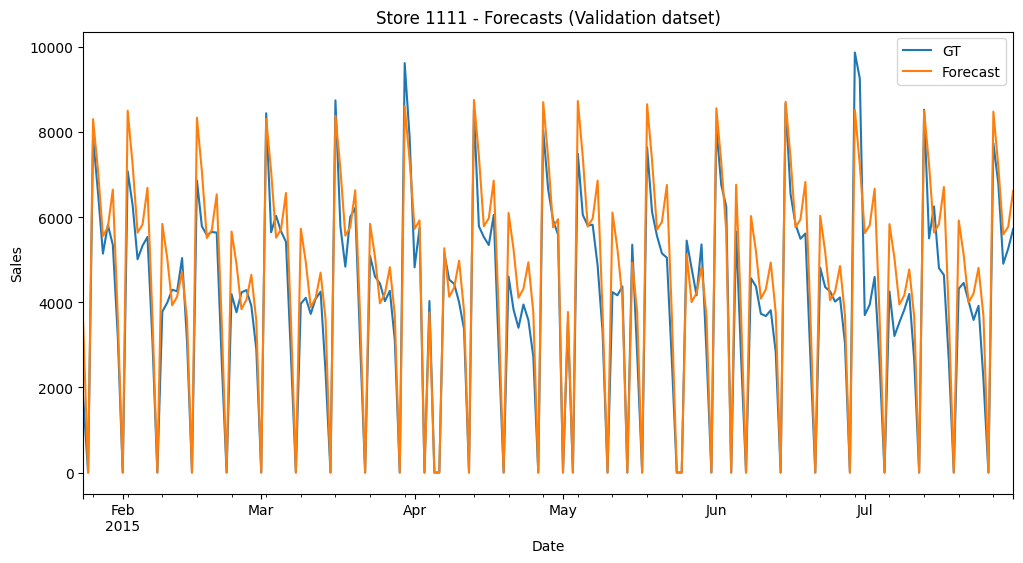

In [24]:
check_sid = 1111
check_res = forecasts_test[forecasts_test["Store"] == check_sid]

fig, ax = plt.subplots(figsize=(12,6))
check_res.plot.line(x="ds", y="y", label="GT", ax=ax)
check_res.plot.line(x="ds", y="yhat", label="Forecast", ax=ax)

ax.set(title=f"Store {check_sid} - Forecasts (Validation datset)",
        xlabel="Date", ylabel="Sales");

#### Build model: XGBoost

Let's move to a gradient boost model called XGBoost. Since it does not understand
time natively as Prophet, we have to perform some adjustments so that it can
find time patterns in the dataset.

In [14]:
mlflow.set_tracking_uri("http://localhost:5001/")
mlflow.set_experiment("forecasting_rossmann_global")

<Experiment: artifact_location='s3://mlflow-artifacts/10', creation_time=1780384687148, experiment_id='10', last_update_time=1780384687148, lifecycle_stage='active', name='forecasting_rossmann_global', tags={}, trace_location=None, workspace='default'>

In [15]:
# Sort values before...
ptrain.sort_values(["Store", "Date"], inplace=True)

In [89]:
categorical_cols = ['StoreType', 'Assortment', 'Cluster']

clustered_train = ptrain.merge(store_features[["Store", "Cluster"]], on="Store", how="left")

train_encoded = pd.get_dummies(clustered_train, columns=categorical_cols, drop_first=True)

# Transform StateHoliday and SchoolHoliday into one column called IsHoliday
train_encoded["IsHoliday"] = np.where((train_encoded["StateHoliday"] != "0") | (train_encoded["SchoolHoliday"] == 1), 1, 0)

drop_features = ["StateHoliday", "SchoolHoliday", "Customers", "PromoInterval", "Promo2SinceWeek", "Promo2SinceYear"]
train_encoded.drop(columns=drop_features, inplace=True)

train_encoded = create_lags_features_rossmann(data=train_encoded, target_feature="Sales")
train_encoded = create_rolling_stats_features_rossmann(data=train_encoded, target_feature="Sales")

train_encoded.head()

,Store,DayOfWeek,Date,Sales,Open,Promo,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,...,Cluster_6,Cluster_7,Cluster_8,IsHoliday,Sales_7,Sales_8,Sales_9,Sales_mean,Sales_sum,Sales_std
0,1,2,2013-01-01,0,0,0,1270.0,9.0,2008.0,0,...,True,False,False,1,NaN,NaN,NaN,NaN,NaN,NaN
1,1,3,2013-01-02,5530,1,0,1270.0,9.0,2008.0,0,...,True,False,False,1,NaN,NaN,NaN,NaN,NaN,NaN
2,1,4,2013-01-03,4327,1,0,1270.0,9.0,2008.0,0,...,True,False,False,1,NaN,NaN,NaN,NaN,NaN,NaN
3,1,5,2013-01-04,4486,1,0,1270.0,9.0,2008.0,0,...,True,False,False,1,NaN,NaN,NaN,NaN,NaN,NaN
4,1,6,2013-01-05,4997,1,0,1270.0,9.0,2008.0,0,...,True,False,False,1,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
date_threshold = "2015-01-01"
e_train = train_encoded[train_encoded["Date"] < date_threshold]
e_test = train_encoded[train_encoded["Date"] >= date_threshold]

features = [col for col in e_train.columns if col not in ['Date', 'Sales', 'Customers']]

X_train = e_train[features]
y_train = e_train['Sales']

X_test = e_test[features]
y_test = e_test['Sales']

print(f"Train size = {X_train.shape}")
print(f"Test size  = {X_test.shape}")

Train size = (780829, 31)
Test size  = (236380, 31)


In [91]:
mlflow.xgboost.autolog()
rn = random.getrandbits(16)

with mlflow.start_run(run_name=f"xgboost_global_{rn}"):
    model_xgb = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=1,
        enable_categorical=True
    )

    model_xgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=50
    )

    preds = model_xgb.predict(X_test)
    preds = np.where(X_test['Open'] == 0, 0, preds)

    pred_smape = smape(y_true=y_test, y_pred=preds)
    print(f"sMAPE = {pred_smape:.3f}")

    mlflow.log_metric("sMAPE_test", round(pred_smape,3))

[0]	validation_0-rmse:3700.70791
[50]	validation_0-rmse:1342.14177
[100]	validation_0-rmse:1232.16281
[150]	validation_0-rmse:1206.22314
[200]	validation_0-rmse:1185.88226
[250]	validation_0-rmse:1168.70213
[300]	validation_0-rmse:1156.89331
[350]	validation_0-rmse:1143.38307
[400]	validation_0-rmse:1133.44893
[450]	validation_0-rmse:1124.97802
[499]	validation_0-rmse:1118.52687


2026/06/04 21:37:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 21:37:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


sMAPE = 12.289
🏃 View run xgboost_global_15301 at: http://localhost:5001/#/experiments/10/runs/822c09fe2ba84ebd8a1fc94b0896dbe8
🧪 View experiment at: http://localhost:5001/#/experiments/10


____